# Ce40-based q-range descriptor results: `q0-11`

Fixed range: `QMIN = 0`, `QMAX = 11`. This notebook was generated from `B-descriptors-Ce40_qrange.ipynb`; outputs belong only to this range.


This notebook aims at training the ML algorithms using structure-related decriptors

**Dataset B**: Calculated PDFs of Ce40-based clusters

**Classes**: Nuclearity classes (1–9)

In [1]:
import os
import matplotlib.pyplot as plt
import glob
import pandas as pd
import numpy as np
from numpy import trapz
import sys
from pathlib import Path

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Locate the project root whether this template or a generated copy is running
PROJECT_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / 'config.py').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.py from the current working directory")
sys.path.insert(0, str(PROJECT_ROOT))

import config
from config import get_path, setup_workdir, qrange_paths, qrange_tag, QRANGE_PAIRS

# --- qrange-study: choose the (qmin, qmax) pair ----------------------------
PAIR_INDEX = 0  # index at generation time; QMIN/QMAX below are fixed
QMIN, QMAX = (0.0, 11.0)
TAG = qrange_tag(QMIN, QMAX)
_qrange = qrange_paths(QMIN, QMAX)
print(f"qrange-study: descriptors for (qmin={QMIN}, qmax={QMAX})  [{TAG}]")

qrange-study: descriptors for (qmin=0.0, qmax=11.0)  [q0-11]


Plot the distribution of cluster nuclearities in the dataset B

Using all 10000 PDFs: {'1': 2188, '2': 2614, '3': 2100, '4': 1433, '5': 857, '6': 472, '7': 215, '8': 95, '9': 26}


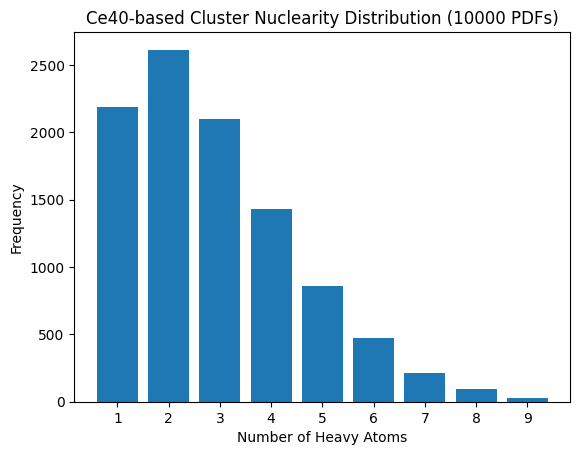

In [2]:
# Use the same complete PDF catalogue used by the models below
pdf_dir = _qrange['ce_calculated_pdfs']
files_for_distribution = sorted(pdf_dir.glob('*.dat'), key=lambda path: path.name)
numbers = [int(path.name[0]) for path in files_for_distribution]

def count_occurrences(values):
    count_dict = {str(i): 0 for i in range(1, 10)}
    for value in values:
        count_dict[str(value)] += 1
    return count_dict

def plot_bar_chart(count_dict):
    nuclearities = list(count_dict.keys())
    counts = list(count_dict.values())

    plt.bar(nuclearities, counts)
    plt.xlabel('Number of Heavy Atoms')
    plt.ylabel('Frequency')
    plt.title(f'Ce40-based Cluster Nuclearity Distribution ({len(numbers)} PDFs)')
    plt.show()

count_dict = count_occurrences(numbers)
print(f"Using all {len(numbers)} PDFs: {count_dict}")
plot_bar_chart(count_dict)

Feature Extraction from PDF Files
- Peak areas and ratios
- Peak positions and heights
- Shell integrals (wider r-range compared to peak area descriptors)
- PDF moments descriptors

PDF files directory: /Volumes/Extreme SSD/WORK/PDF/PDF-NN paper/PDF-NN/pdf-nn-data/ce_clusters/calculated_pdfs_q0-11
Found 10000 PDF files to process


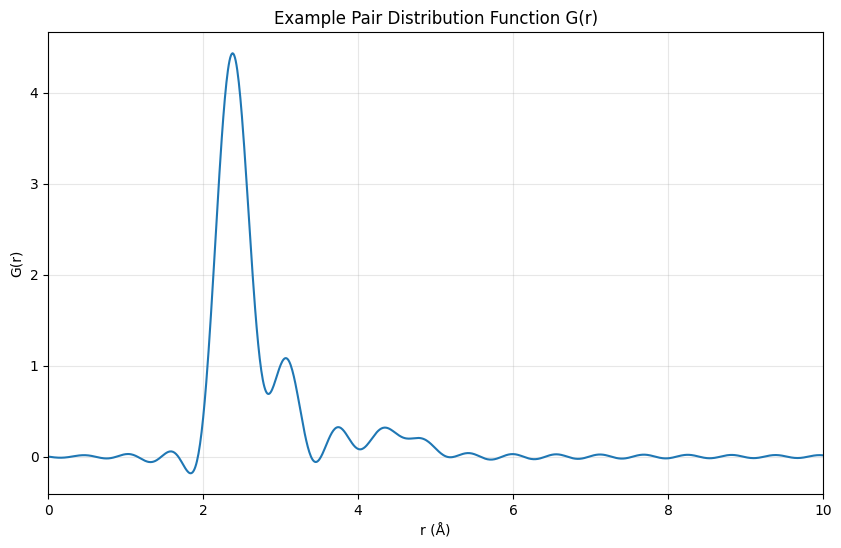

In [3]:
# Select the namespaced PDF input for this q range
pdf_dir = _qrange['ce_calculated_pdfs']
print(f"PDF files directory: {pdf_dir}")

# Stable ordering keeps the same structures in each train/test split across q ranges
files_pdf = sorted(pdf_dir.glob('*.dat'), key=lambda path: path.name)
print(f"Found {len(files_pdf)} PDF files to process")

# Plot example PDF
if len(files_pdf) > 0:
    example_file = files_pdf[0]
    data = pd.read_csv(example_file, skiprows=1, sep=r'\s+', index_col=False)
    data.columns = ['r', 'g']

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(data.r, data.g)
    ax.set_xlim(0, 10)
    ax.set_xlabel('r (Å)')
    ax.set_ylabel('G(r)')
    ax.set_title('Example Pair Distribution Function G(r)')
    ax.grid(True, alpha=0.3)
    plt.show()


In [4]:
print(f"Extracting features from {len(files_pdf)} PDF files...")

def extract_pdf_features(df):
    """Extract comprehensive PDF features for classification"""
    features = {}
    
    # Define peak regions
    peak1_mask = (df['r'] >= 2.0) & (df['r'] <= 3.0)
    peak2_mask = (df['r'] >= 3.5) & (df['r'] <= 4.2) 
    peak3_mask = (df['r'] >= 6.0) & (df['r'] <= 7.0)
    
    peak1 = df.loc[peak1_mask]
    peak2 = df.loc[peak2_mask]
    peak3 = df.loc[peak3_mask]
    
    # Peak areas (integrals of G(r))
    area1 = trapz(peak1.g, peak1.r) if len(peak1) > 0 else 0
    area2 = trapz(peak2.g, peak2.r) if len(peak2) > 0 else 0
    area3 = trapz(peak3.g, peak3.r) if len(peak3) > 0 else 0
    
    features['area1'] = area1
    features['area2'] = area2  
    features['area3'] = area3
    
    # Peak intensity ratios
    features['ratio_21'] = area2/area1 if area1 > 0 else 0
    features['ratio_23'] = area2/area3 if area3 > 0 else 0
    features['ratio_31'] = area3/area1 if area1 > 0 else 0
    
    # Peak positions (r-values at maximum intensity)
    features['peak1_pos'] = peak1.loc[peak1.g.idxmax(), 'r'] if len(peak1) > 0 and peak1.g.max() > 0 else 2.5
    features['peak2_pos'] = peak2.loc[peak2.g.idxmax(), 'r'] if len(peak2) > 0 and peak2.g.max() > 0 else 3.85
    features['peak3_pos'] = peak3.loc[peak3.g.idxmax(), 'r'] if len(peak3) > 0 and peak3.g.max() > 0 else 6.5
    
    # Peak heights (maximum intensities)
    features['peak1_height'] = peak1.g.max() if len(peak1) > 0 else 0
    features['peak2_height'] = peak2.g.max() if len(peak2) > 0 else 0
    features['peak3_height'] = peak3.g.max() if len(peak3) > 0 else 0
    
    # Peak height ratios
    features['height_21'] = features['peak2_height']/features['peak1_height'] if features['peak1_height'] > 0 else 0
    features['height_31'] = features['peak3_height']/features['peak1_height'] if features['peak1_height'] > 0 else 0
    
    # Coordination shell integrals (broader regions)
    shell1_mask = (df['r'] >= 1.5) & (df['r'] <= 3.5)
    shell2_mask = (df['r'] >= 3.0) & (df['r'] <= 5.0)
    shell3_mask = (df['r'] >= 5.5) & (df['r'] <= 7.5)
    
    features['shell1'] = trapz(df.loc[shell1_mask, 'g'], df.loc[shell1_mask, 'r']) if shell1_mask.any() else 0
    features['shell2'] = trapz(df.loc[shell2_mask, 'g'], df.loc[shell2_mask, 'r']) if shell2_mask.any() else 0
    features['shell3'] = trapz(df.loc[shell3_mask, 'g'], df.loc[shell3_mask, 'r']) if shell3_mask.any() else 0
    
    # PDF moments and shape descriptors
    r_vals = df['r'].values
    g_vals = df['g'].values
    
    # For PDF, handle negative values by using positive part only
    g_pos = np.maximum(g_vals, 0)
    
    # First moment (weighted average r-position of positive peaks)
    if np.sum(g_pos) > 0:
        features['moment1'] = np.sum(r_vals * g_pos) / np.sum(g_pos)
        features['moment2'] = np.sum((r_vals - features['moment1'])**2 * g_pos) / np.sum(g_pos)  # Variance
    else:
        features['moment1'] = 0
        features['moment2'] = 0
    
    # Total PDF integral (0-10 Å)
    total_mask = (df['r'] >= 0) & (df['r'] <= 10)
    features['total_integral'] = trapz(df.loc[total_mask, 'g'], df.loc[total_mask, 'r']) if total_mask.any() else 0
    
    return features

feature_names = [
    'nuclearity', 'area1', 'area2', 'area3', 'ratio_21', 'ratio_23', 'ratio_31',
    'peak1_pos', 'peak2_pos', 'peak3_pos', 'peak1_height', 'peak2_height', 'peak3_height',
    'height_21', 'height_31', 'shell1', 'shell2', 'shell3',
    'moment1', 'moment2', 'total_integral',
]

all_features = []
failed_files = []
for i, file_path in enumerate(files_pdf):
    try:
        data = pd.read_csv(file_path, skiprows=1, sep=r'\s+', index_col=False)
        data.columns = ['r', 'g']
        features = extract_pdf_features(data)
        nuclearity = int(file_path.name[0])
        all_features.append([nuclearity] + [features[name] for name in feature_names[1:]])
    except Exception as error:
        failed_files.append((file_path.name, str(error)))

    if i == 0 or (i + 1) % 1000 == 0:
        print(f"Processed {i + 1} files...")

if failed_files:
    preview = '\n'.join(f"  {name}: {error}" for name, error in failed_files[:10])
    raise RuntimeError(f"Feature extraction failed for {len(failed_files)} file(s):\n{preview}")

features_data = pd.DataFrame(all_features, columns=feature_names)
print(f"Feature extraction complete: {len(features_data)} samples, {len(feature_names) - 1} features")

Extracting features from 10000 PDF files...


Processed 1 files...


Processed 1000 files...


Processed 2000 files...


Processed 3000 files...


...

Processed 6000 files...


Processed 7000 files...


Processed 8000 files...


Processed 9000 files...


Processed 10000 files...
Feature extraction complete: 10000 samples, 20 features


Loaded 10000 samples with 20 features
Nuclearity distribution:
nuclearity
1    2188
2    2614
3    2100
4    1433
5     857
6     472
7     215
8      95
9      26
Name: count, dtype: int64


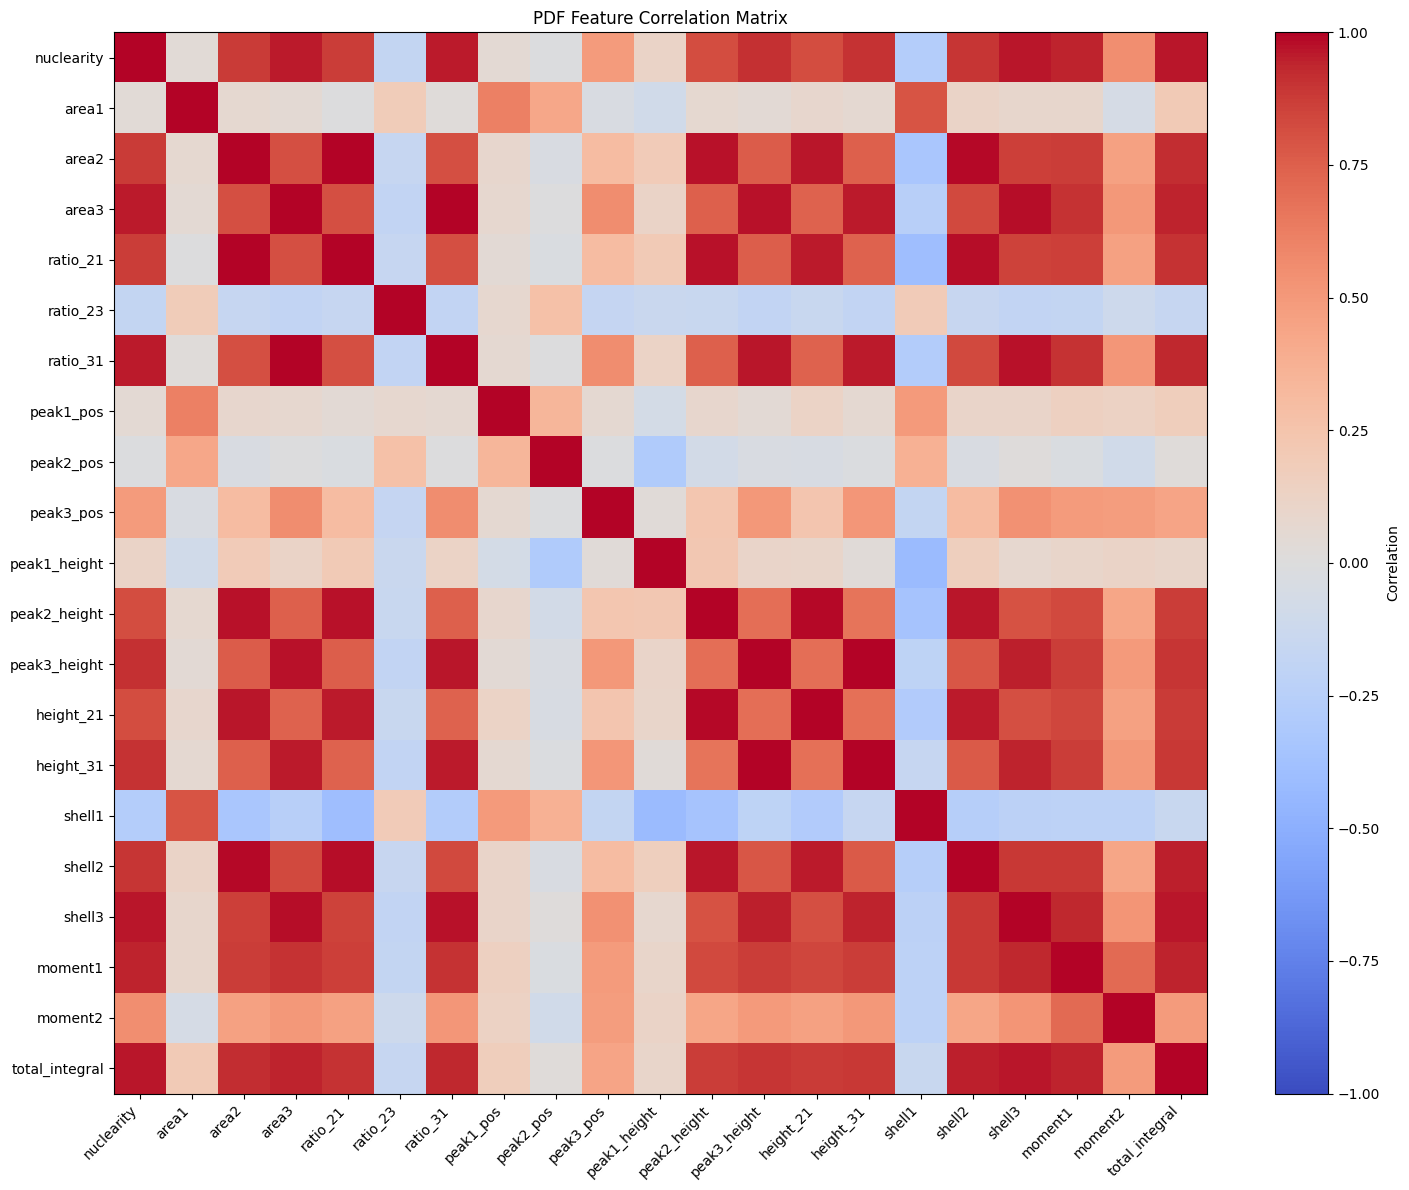

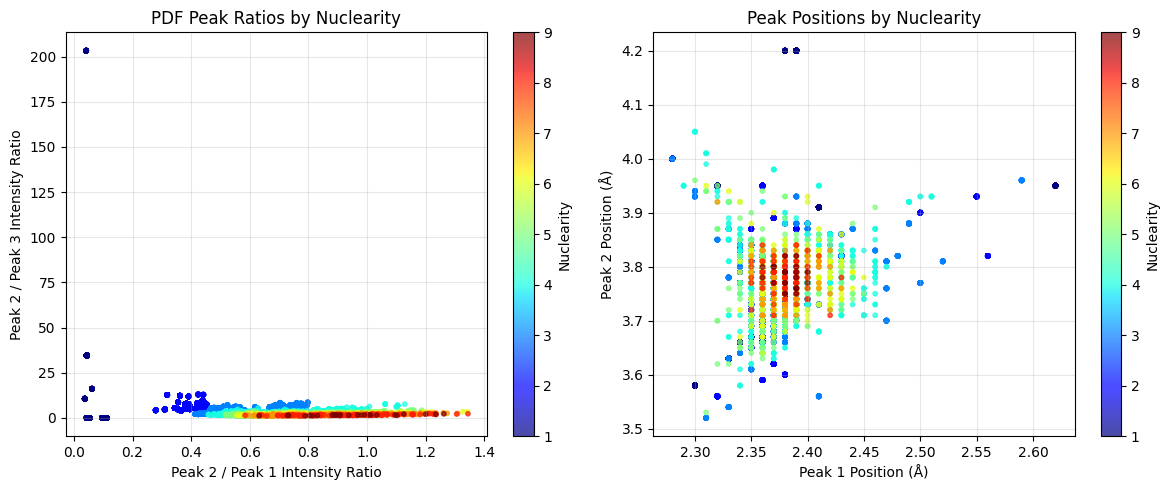

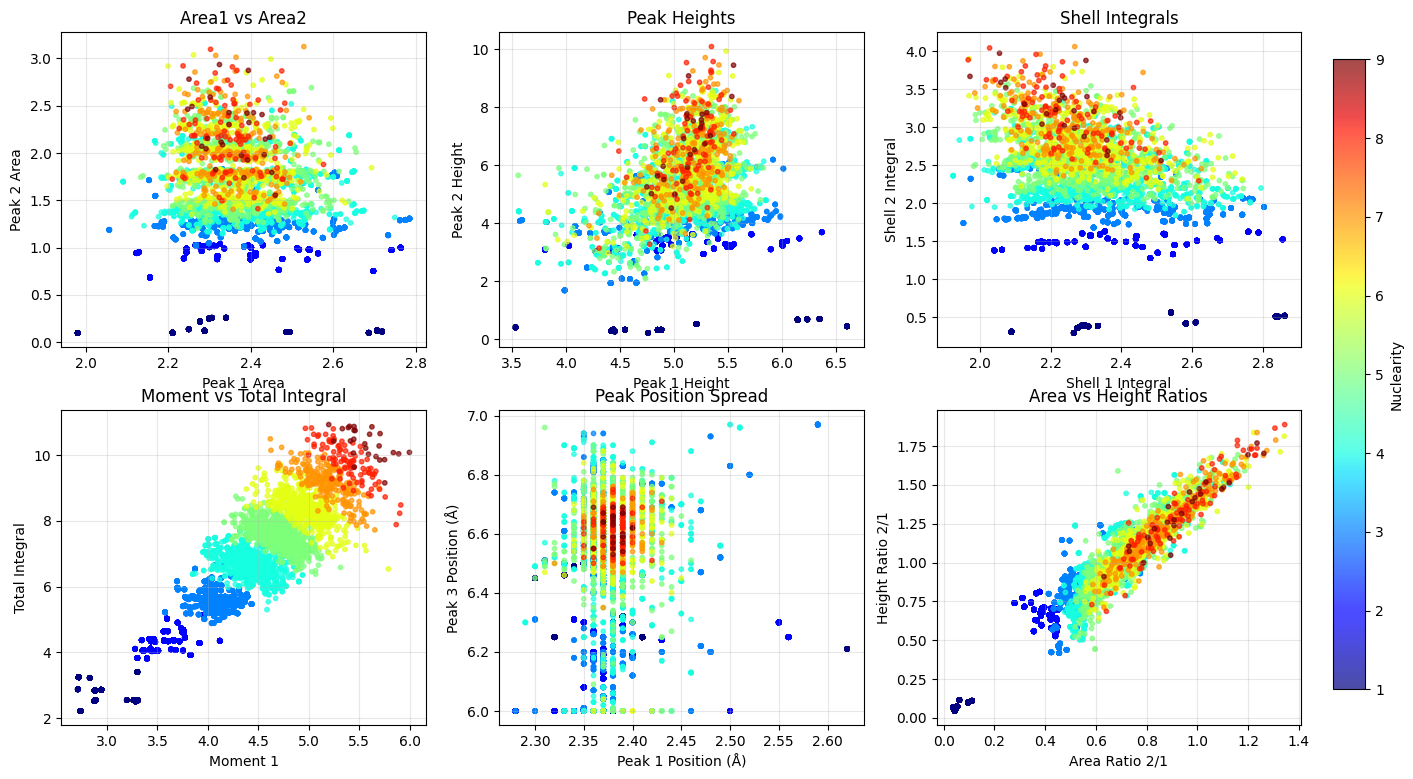


Feature statistics:
       nuclearity      area1      area2      area3   ratio_21   ratio_23  \
count   10000.000  10000.000  10000.000  10000.000  10000.000  10000.000   
mean        2.906      2.372      1.090      0.377      0.460      5.026   
std         1.647      0.153      0.625      0.365      0.265     12.152   
min         1.000      1.981      0.098     -0.017      0.037      0.000   
25%         2.000      2.287      0.873      0.101      0.344      1.708   
50%         3.000      2.357      1.129      0.239      0.458      2.708   
75%         4.000      2.456      1.484      0.602      0.628      5.974   
max         9.000      2.785      3.124      1.802      1.344    203.258   

        ratio_31  peak1_pos  peak2_pos  peak3_pos  ...  peak2_height  \
count  10000.000  10000.000  10000.000  10000.000  ...     10000.000   
mean       0.159      2.376      3.770      6.362  ...         3.522   
std        0.154      0.046      0.118      0.253  ...         2.023   
min   

In [5]:
# Visualize the in-memory PDF features
print(f"Loaded {len(features_data)} samples with {len(feature_names)-1} features")
print(f"Nuclearity distribution:")
print(features_data['nuclearity'].value_counts().sort_index())

# Visualize feature correlations
plt.figure(figsize=(15, 12))
correlation_matrix = features_data.corr()
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
plt.yticks(range(len(feature_names)), feature_names)
plt.title('PDF Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Create enhanced scatter plot with original ratios
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(features_data['ratio_21'], features_data['ratio_23'], 
                      c=features_data['nuclearity'], cmap='jet', s=10, alpha=0.7)
plt.xlabel('Peak 2 / Peak 1 Intensity Ratio')
plt.ylabel('Peak 2 / Peak 3 Intensity Ratio')
plt.title('PDF Peak Ratios by Nuclearity')
plt.colorbar(scatter1, label='Nuclearity')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(features_data['peak1_pos'], features_data['peak2_pos'], 
                      c=features_data['nuclearity'], cmap='jet', s=10, alpha=0.7)
plt.xlabel('Peak 1 Position (Å)')
plt.ylabel('Peak 2 Position (Å)')
plt.title('Peak Positions by Nuclearity')
plt.colorbar(scatter2, label='Nuclearity')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional scatter plots for clustering insight
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
scatter_kwargs = dict(c=features_data['nuclearity'], cmap='jet', s=10, alpha=0.7)

axes[0, 0].scatter(features_data['area1'], features_data['area2'], **scatter_kwargs)
axes[0, 0].set_xlabel('Peak 1 Area')
axes[0, 0].set_ylabel('Peak 2 Area')
axes[0, 0].set_title('Area1 vs Area2')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(features_data['peak1_height'], features_data['peak2_height'], **scatter_kwargs)
axes[0, 1].set_xlabel('Peak 1 Height')
axes[0, 1].set_ylabel('Peak 2 Height')
axes[0, 1].set_title('Peak Heights')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(features_data['shell1'], features_data['shell2'], **scatter_kwargs)
axes[0, 2].set_xlabel('Shell 1 Integral')
axes[0, 2].set_ylabel('Shell 2 Integral')
axes[0, 2].set_title('Shell Integrals')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].scatter(features_data['moment1'], features_data['total_integral'], **scatter_kwargs)
axes[1, 0].set_xlabel('Moment 1')
axes[1, 0].set_ylabel('Total Integral')
axes[1, 0].set_title('Moment vs Total Integral')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(features_data['peak1_pos'], features_data['peak3_pos'], **scatter_kwargs)
axes[1, 1].set_xlabel('Peak 1 Position (Å)')
axes[1, 1].set_ylabel('Peak 3 Position (Å)')
axes[1, 1].set_title('Peak Position Spread')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].scatter(features_data['ratio_21'], features_data['height_21'], **scatter_kwargs)
axes[1, 2].set_xlabel('Area Ratio 2/1')
axes[1, 2].set_ylabel('Height Ratio 2/1')
axes[1, 2].set_title('Area vs Height Ratios')
axes[1, 2].grid(True, alpha=0.3)

fig.colorbar(axes[0, 0].collections[0], ax=axes, label='Nuclearity', shrink=1, cax=fig.add_axes([0.92, 0.15, 0.02, 0.7]))
plt.show()

# Display feature statistics
print("\nFeature statistics:")
print(features_data.describe().round(3))

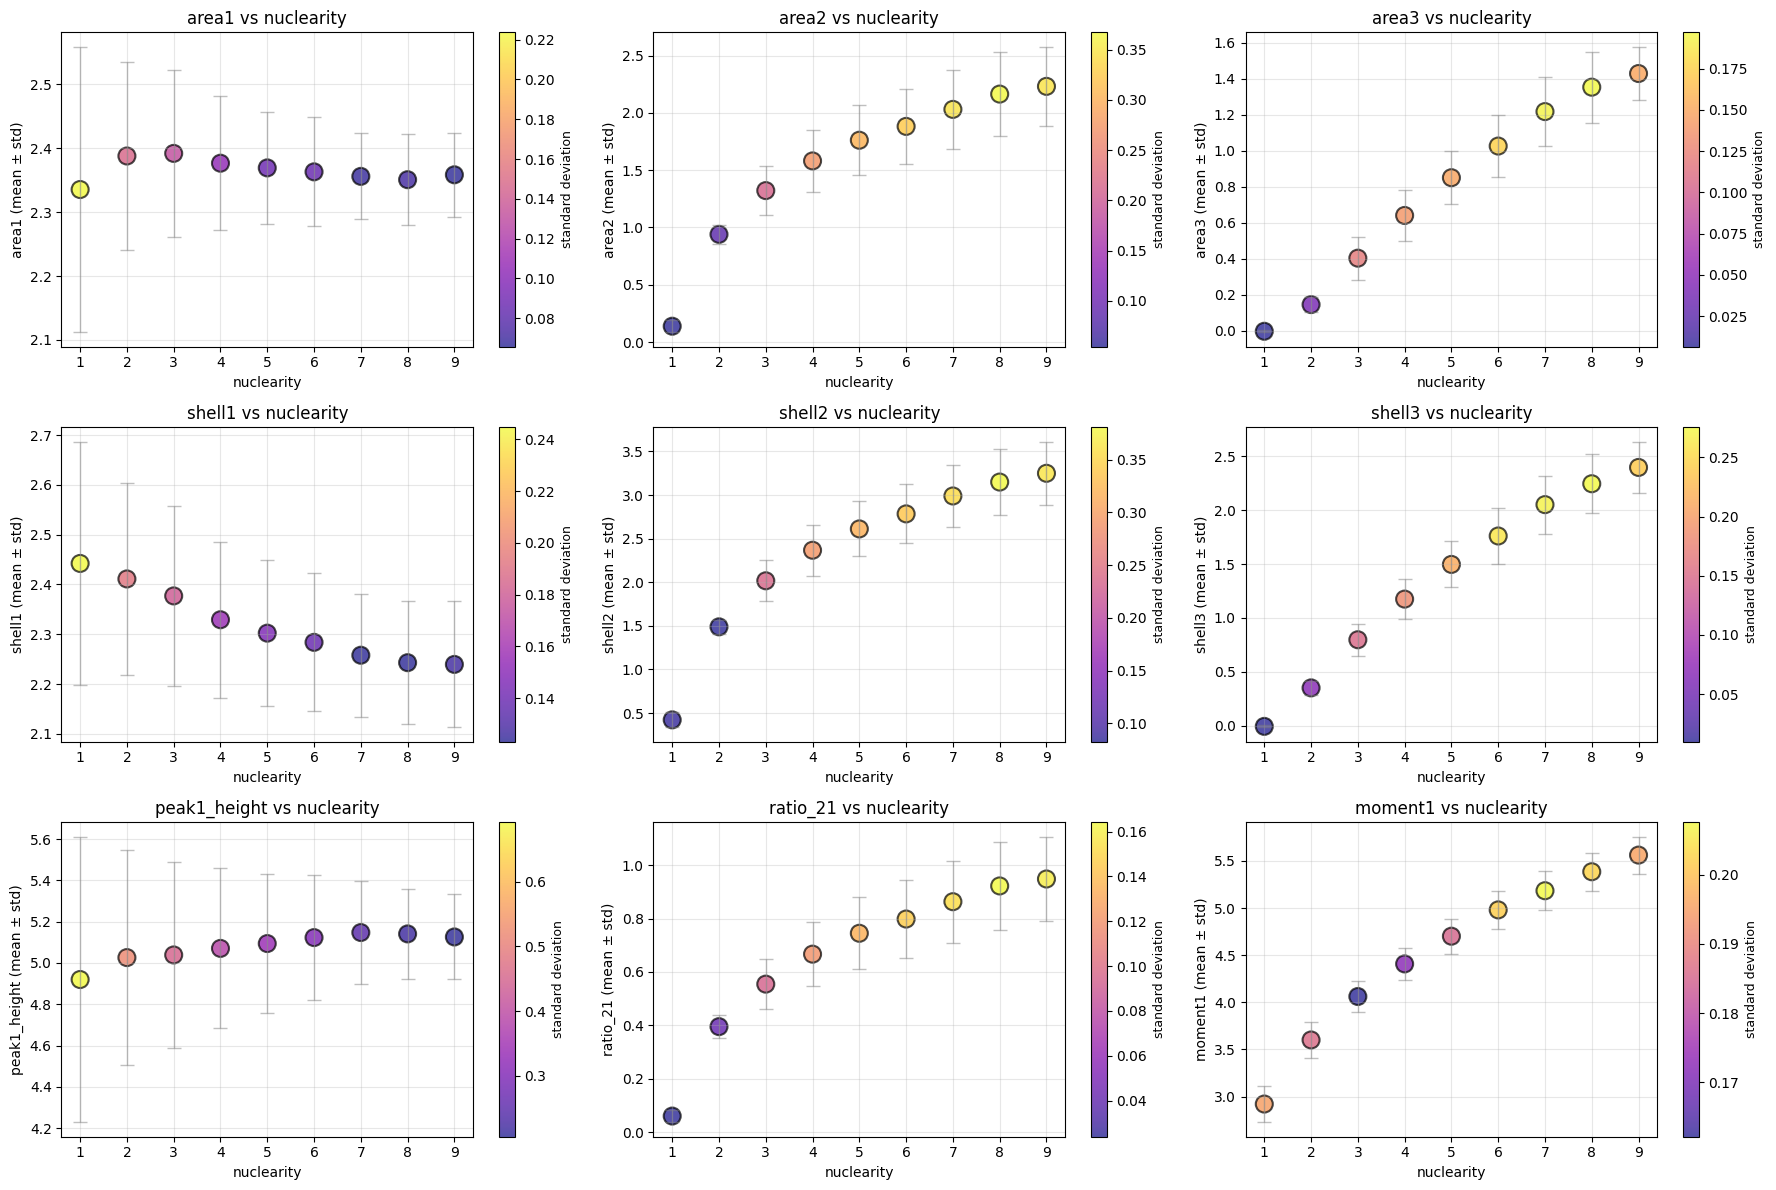

In [6]:
# Feature vs nuclearity with dispersion analysis
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes_flat = axes.flatten()

# Calculate mean and std for each feature grouped by nuclearity
feature_dispersion = {}
nuclearity_values = sorted(features_data['nuclearity'].unique())

# Select key features for visualization
key_features = ['area1', 'area2', 'area3', 'shell1', 'shell2', 'shell3', 'peak1_height', 'ratio_21', 'moment1']

for idx, feature in enumerate(key_features):
    ax = axes_flat[idx]
    
    # Calculate mean and std for each nuclearity
    feature_means = []
    feature_stds = []
    
    for nuc in nuclearity_values:
        nuc_data = features_data[features_data['nuclearity'] == nuc][feature]
        feature_means.append(nuc_data.mean())
        feature_stds.append(nuc_data.std())
    
    # Create scatter plot: nuclearity vs feature value, colored by dispersion (std)
    scatter = ax.scatter(nuclearity_values, feature_means, 
                        c=feature_stds, cmap='plasma', s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    # Add error bars showing std deviation
    ax.errorbar(nuclearity_values, feature_means, yerr=feature_stds, fmt='none', 
               ecolor='gray', alpha=0.5, capsize=5, linewidth=1)
    
    ax.set_xlabel('nuclearity')
    ax.set_ylabel(f'{feature} (mean ± std)')
    ax.set_title(f'{feature} vs nuclearity')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(nuclearity_values)
    
    # Add colorbar for this subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('standard deviation', fontsize=9)

# Hide any unused subplots
for j in range(len(key_features), len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()


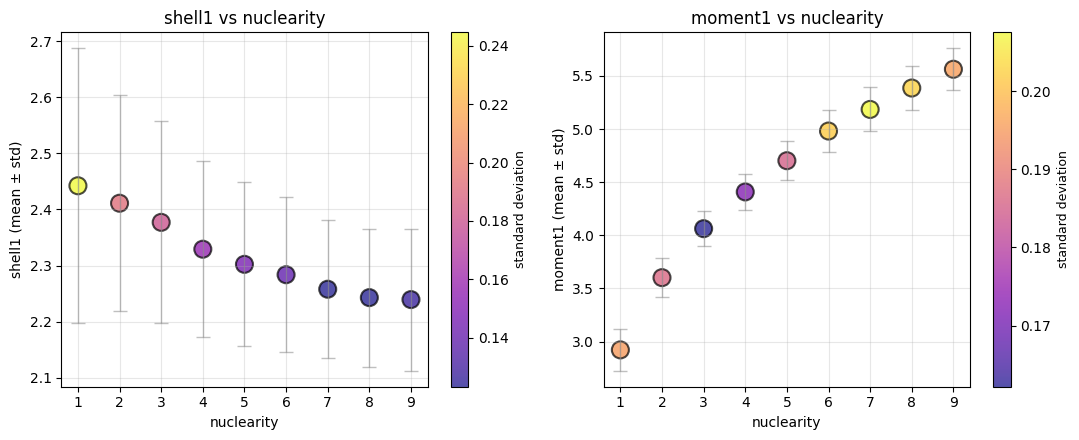

In [7]:
# Feature vs nuclearity with dispersion analysis
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes_flat = axes.flatten()

# Calculate mean and std for each feature grouped by nuclearity
feature_dispersion = {}
nuclearity_values = sorted(features_data['nuclearity'].unique())

# Select key features for visualization
key_features = ['shell1', 'moment1']

for idx, feature in enumerate(key_features):
    ax = axes_flat[idx]
    
    # Calculate mean and std for each nuclearity
    feature_means = []
    feature_stds = []
    
    for nuc in nuclearity_values:
        nuc_data = features_data[features_data['nuclearity'] == nuc][feature]
        feature_means.append(nuc_data.mean())
        feature_stds.append(nuc_data.std())
    
    # Create scatter plot: nuclearity vs feature value, colored by dispersion (std)
    scatter = ax.scatter(nuclearity_values, feature_means, 
                        c=feature_stds, cmap='plasma', s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    # Add error bars showing std deviation
    ax.errorbar(nuclearity_values, feature_means, yerr=feature_stds, fmt='none', 
               ecolor='gray', alpha=0.5, capsize=5, linewidth=1)
    
    ax.set_xlabel('nuclearity')
    ax.set_ylabel(f'{feature} (mean ± std)')
    ax.set_title(f'{feature} vs nuclearity')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(nuclearity_values)
    
    # Add colorbar for this subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('standard deviation', fontsize=9)

plt.tight_layout()
plt.show()


## Model Training: Gradient Boosting Classifier

Feature matrix shape: (10000, 20)
Target distribution: [   0 2188 2614 2100 1433  857  472  215   95   26]
Training Gradient Boosting Classifier on PDF features...



Gradient Boosting Classification Results (PDF features):
Accuracy: 0.990
F1-score (weighted): 0.989
F1-score (macro): 0.896

Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       438
           2       1.00      1.00      1.00       523
           3       1.00      1.00      1.00       420
           4       0.99      1.00      0.99       287
           5       1.00      0.98      0.99       171
           6       0.96      0.98      0.97        94
           7       0.83      0.91      0.87        43
           8       0.73      0.58      0.65        19
           9       0.60      0.60      0.60         5

    accuracy                           0.99      2000
   macro avg       0.90      0.89      0.90      2000
weighted avg       0.99      0.99      0.99      2000




Cross-validation F1-scores: [0.98938248 0.98937225 0.9860137  0.9913326  0.99103769]
Mean CV F1-score: 0.989 (+/- 0.004)


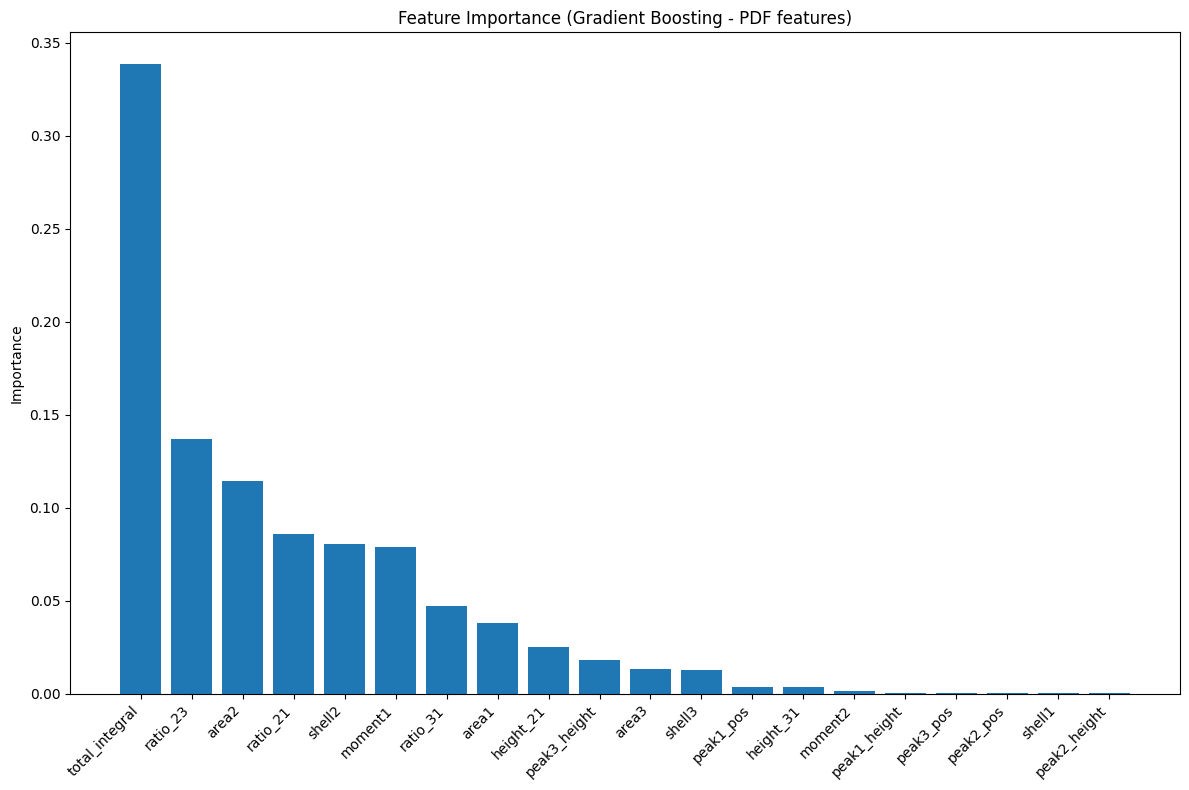


Top 5 most important PDF features:
1. total_integral: 0.339
2. ratio_23: 0.137
3. area2: 0.114
4. ratio_21: 0.086
5. shell2: 0.081


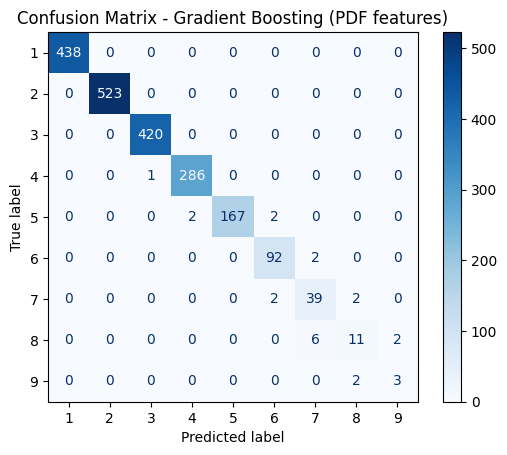

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Prepare data for classification
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution: {np.bincount(y)}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(
    n_estimators=300, 
    learning_rate=0.1, 
    max_depth=6,
    random_state=42
)

print("Training Gradient Boosting Classifier on PDF features...")
gb_classifier.fit(X_train_scaled, y_train)

# Make predictions
y_pred = gb_classifier.predict(X_test_scaled)

# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"\nGradient Boosting Classification Results (PDF features):")
print(f"Accuracy: {accuracy:.3f}")
print(f"F1-score (weighted): {f1_weighted:.3f}")
print(f"F1-score (macro): {f1_macro:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Cross-validation performance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb_classifier, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')
print(f"\nCross-validation F1-scores: {cv_scores}")
print(f"Mean CV F1-score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Feature importance
feature_importance = gb_classifier.feature_importances_
feature_names_clean = feature_names[1:]  # Remove 'nuclearity'

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance)[::-1]
plt.bar(range(len(feature_importance)), feature_importance[indices])
plt.xticks(range(len(feature_importance)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Gradient Boosting - PDF features)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important PDF features:")
for i in range(5):
    idx = indices[i]
    print(f"{i+1}. {feature_names_clean[idx]}: {feature_importance[idx]:.3f}")

# Confusion matrix
classes = sorted(np.unique(y))
conf_matrix = confusion_matrix(y_test, y_pred, labels=classes)
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=classes)
display.plot(cmap='Blues', values_format='d', colorbar=True)
display.ax_.set_title('Confusion Matrix - Gradient Boosting (PDF features)')
plt.show()

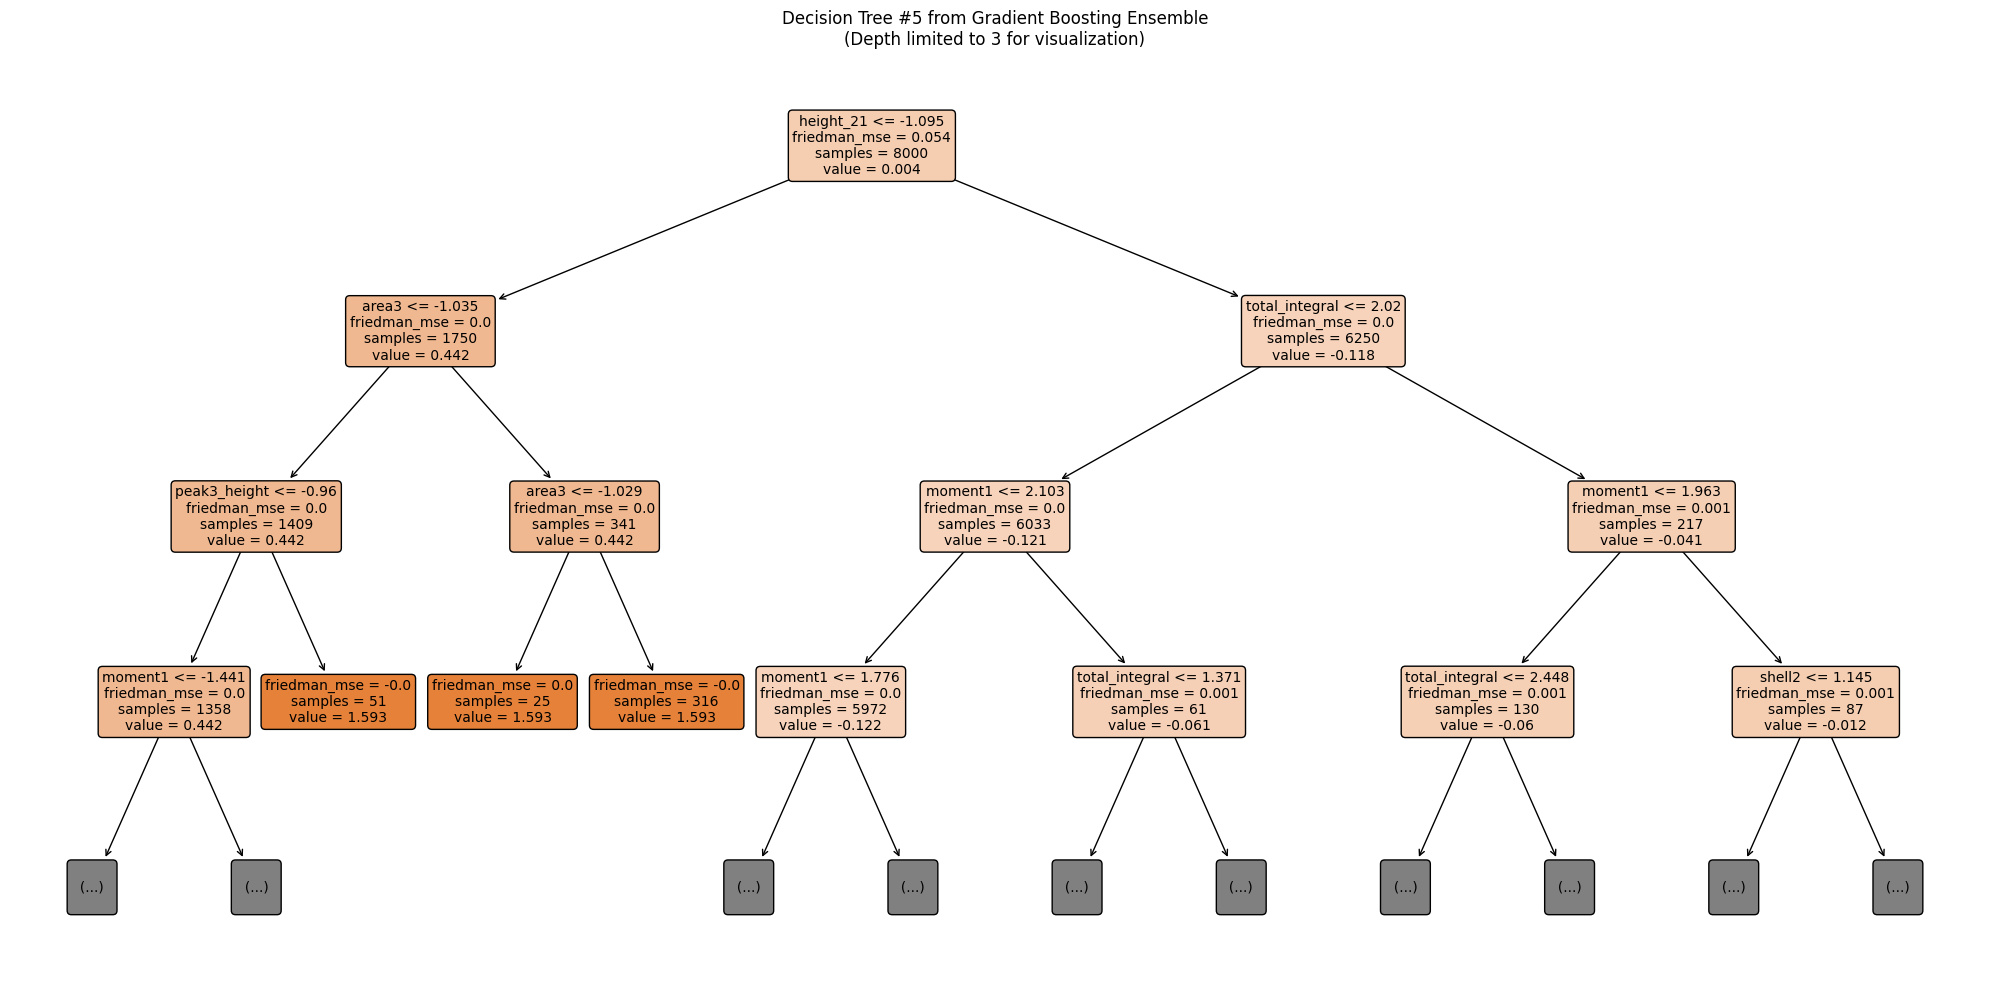

Tree #5 details:
  Number of nodes: 73
  Maximum depth: 6
  Number of leaves: 37


In [9]:
# Visualize a single tree from the Gradient Boosting ensemble
from sklearn.tree import plot_tree

# Select a tree to visualize (e.g., the 5th estimator)
tree_index = 4  # 5th tree (0-indexed)

plt.figure(figsize=(20, 10))
plot_tree(
    gb_classifier.estimators_[tree_index, 0],
    feature_names=feature_names_clean,
    class_names=[str(i) for i in sorted(np.unique(y))],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # Limit depth for visualization clarity
)
plt.title(f'Decision Tree #{tree_index + 1} from Gradient Boosting Ensemble\n(Depth limited to 3 for visualization)')
plt.tight_layout()
plt.show()

print(f"Tree #{tree_index + 1} details:")
print(f"  Number of nodes: {gb_classifier.estimators_[tree_index, 0].tree_.node_count}")
print(f"  Maximum depth: {gb_classifier.estimators_[tree_index, 0].tree_.max_depth}")
print(f"  Number of leaves: {gb_classifier.estimators_[tree_index, 0].tree_.n_leaves}")

## Model Training: Random Forest Classifier

Training Random Forest Classifier with hyperparameter tuning...
Fitting 3 folds for each of 48 candidates, totalling 144 fits


Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV score: 0.988

Random Forest Classification Results (PDF features):
Accuracy: 0.988
F1-score (weighted): 0.987
F1-score (macro): 0.865

Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       438
           2       1.00      1.00      1.00       523
           3       1.00      1.00      1.00       420
           4       1.00      1.00      1.00       287
           5       0.99      0.98      0.99       171
           6       0.90      0.95      0.92        94
           7       0.82      0.84      0.83        43
           8       0.76      0.68      0.72        19
           9       1.00      0.20      0.33         5

    accuracy                           0.99      2000
   macro avg       0.94      0.85      0.87      2000
weighted avg       0.99      0.99      0.99   

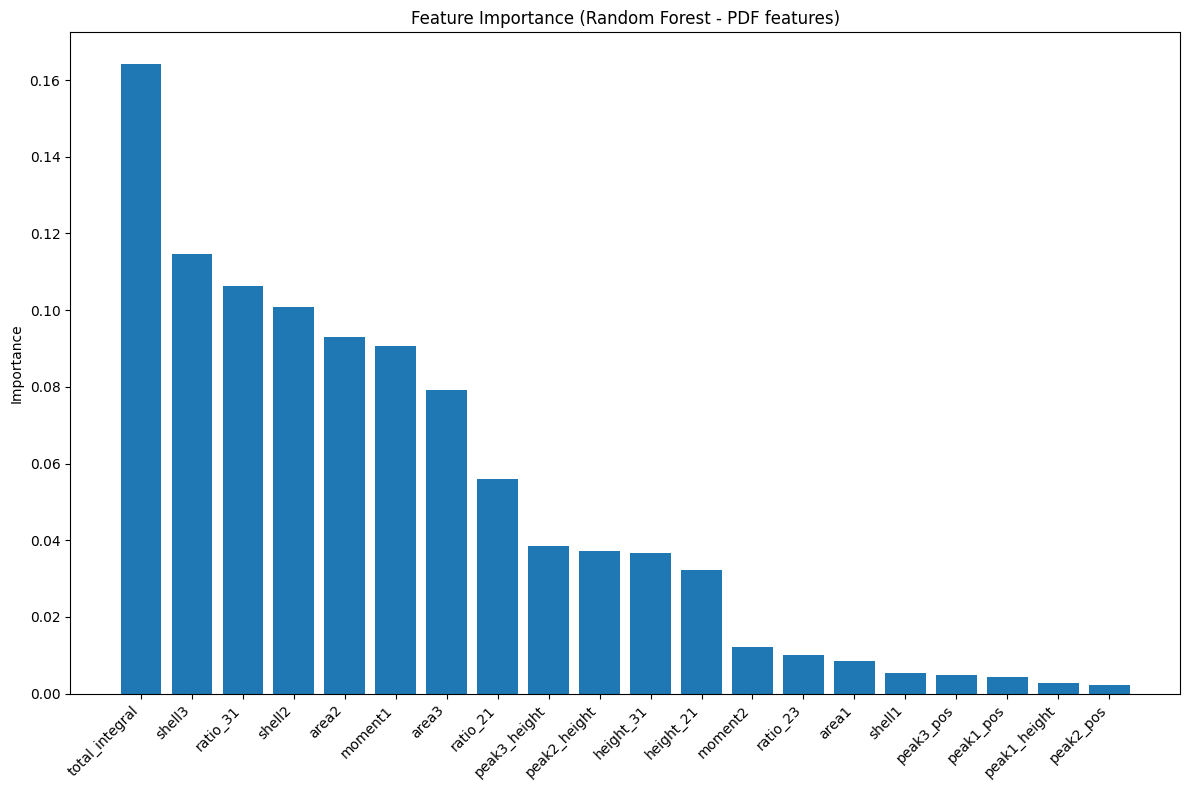


Top 5 most important PDF features (Random Forest):
1. total_integral: 0.164
2. shell3: 0.115
3. ratio_31: 0.106
4. shell2: 0.101
5. area2: 0.093


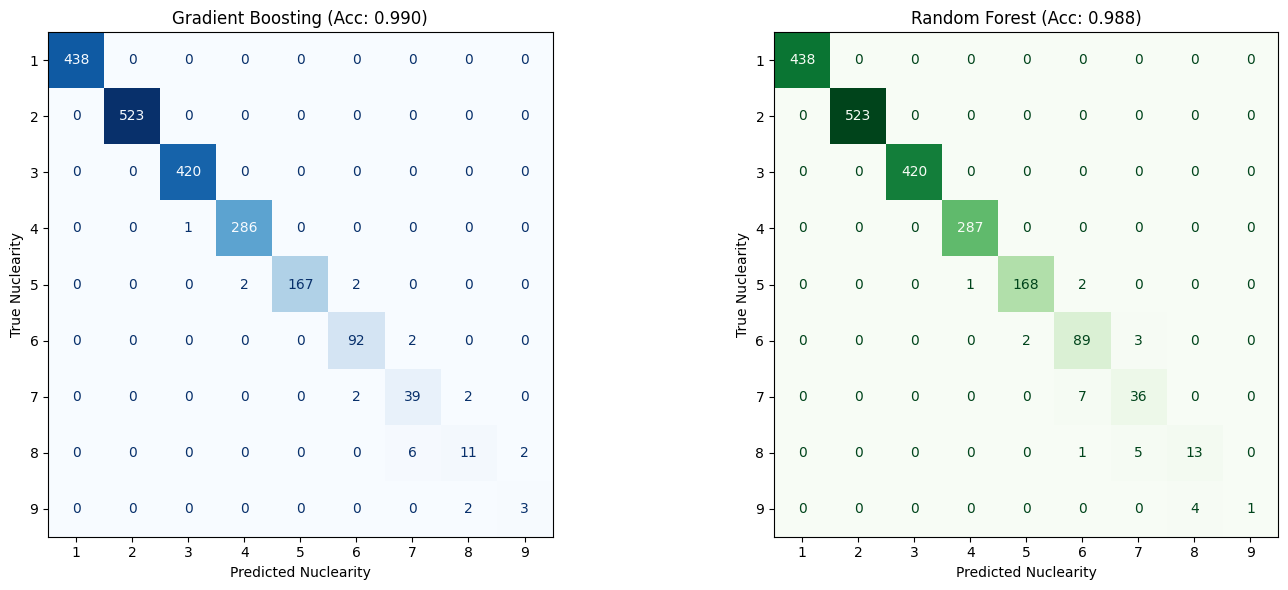


Per-class accuracy comparison:
Class      GB Precision    RF Precision    GB Recall    RF Recall   
----------------------------------------------------------------------
1          1.000           1.000           1.000        1.000       
2          1.000           1.000           1.000        1.000       
3          0.998           1.000           1.000        1.000       
4          0.993           0.997           0.997        1.000       
5          1.000           0.988           0.977        0.982       
6          0.958           0.899           0.979        0.947       
7          0.830           0.818           0.907        0.837       
8          0.733           0.765           0.579        0.684       
9          0.600           1.000           0.600        0.200       


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("Training Random Forest Classifier with hyperparameter tuning...")

# Define parameter grid for optimization
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_classifier = RandomForestClassifier(random_state=42)

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    rf_classifier, 
    param_grid, 
    cv=3, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_scaled, y_train)

# Get best model
best_rf = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.3f}")

# Make predictions with best model
y_pred_rf = best_rf.predict(X_test_scaled)

# Calculate classification metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted')
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')

print(f"\nRandom Forest Classification Results (PDF features):")
print(f"Accuracy: {accuracy_rf:.3f}")
print(f"F1-score (weighted): {f1_weighted_rf:.3f}")
print(f"F1-score (macro): {f1_macro_rf:.3f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Feature importance analysis
feature_importance_rf = best_rf.feature_importances_
feature_names_clean = feature_names[1:]  # Remove 'nuclearity'

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance_rf)[::-1]
plt.bar(range(len(feature_importance_rf)), feature_importance_rf[indices])
plt.xticks(range(len(feature_importance_rf)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Random Forest - PDF features)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important PDF features (Random Forest):")
for i in range(5):
    idx = indices[i]
    print(f"{i+1}. {feature_names_clean[idx]}: {feature_importance_rf[idx]:.3f}")

# Confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
classes = sorted(np.unique(y))

# Gradient Boosting confusion matrix
conf_matrix_gb = confusion_matrix(y_test, y_pred, labels=classes)
ConfusionMatrixDisplay(confusion_matrix=conf_matrix_gb, display_labels=classes).plot(
    ax=axes[0], cmap='Blues', values_format='d', colorbar=False
)
axes[0].set_xlabel('Predicted Nuclearity')
axes[0].set_ylabel('True Nuclearity')
axes[0].set_title(f'Gradient Boosting (Acc: {accuracy:.3f})')

# Random Forest confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf, labels=classes)
ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf, display_labels=classes).plot(
    ax=axes[1], cmap='Greens', values_format='d', colorbar=False
)
axes[1].set_xlabel('Predicted Nuclearity')
axes[1].set_ylabel('True Nuclearity')
axes[1].set_title(f'Random Forest (Acc: {accuracy_rf:.3f})')

plt.tight_layout()
plt.show()

# Calculate per-class accuracy
from sklearn.metrics import precision_score, recall_score

unique_classes = sorted(np.unique(y))
print(f"\nPer-class accuracy comparison:")
print(f"{'Class':<10} {'GB Precision':<15} {'RF Precision':<15} {'GB Recall':<12} {'RF Recall':<12}")
print("-" * 70)

for cls in unique_classes:
    gb_prec = precision_score(y_test == cls, y_pred == cls, zero_division=0)
    rf_prec = precision_score(y_test == cls, y_pred_rf == cls, zero_division=0)
    gb_rec = recall_score(y_test == cls, y_pred == cls, zero_division=0)
    rf_rec = recall_score(y_test == cls, y_pred_rf == cls, zero_division=0)
    print(f"{cls:<10} {gb_prec:<15.3f} {rf_prec:<15.3f} {gb_rec:<12.3f} {rf_rec:<12.3f}")

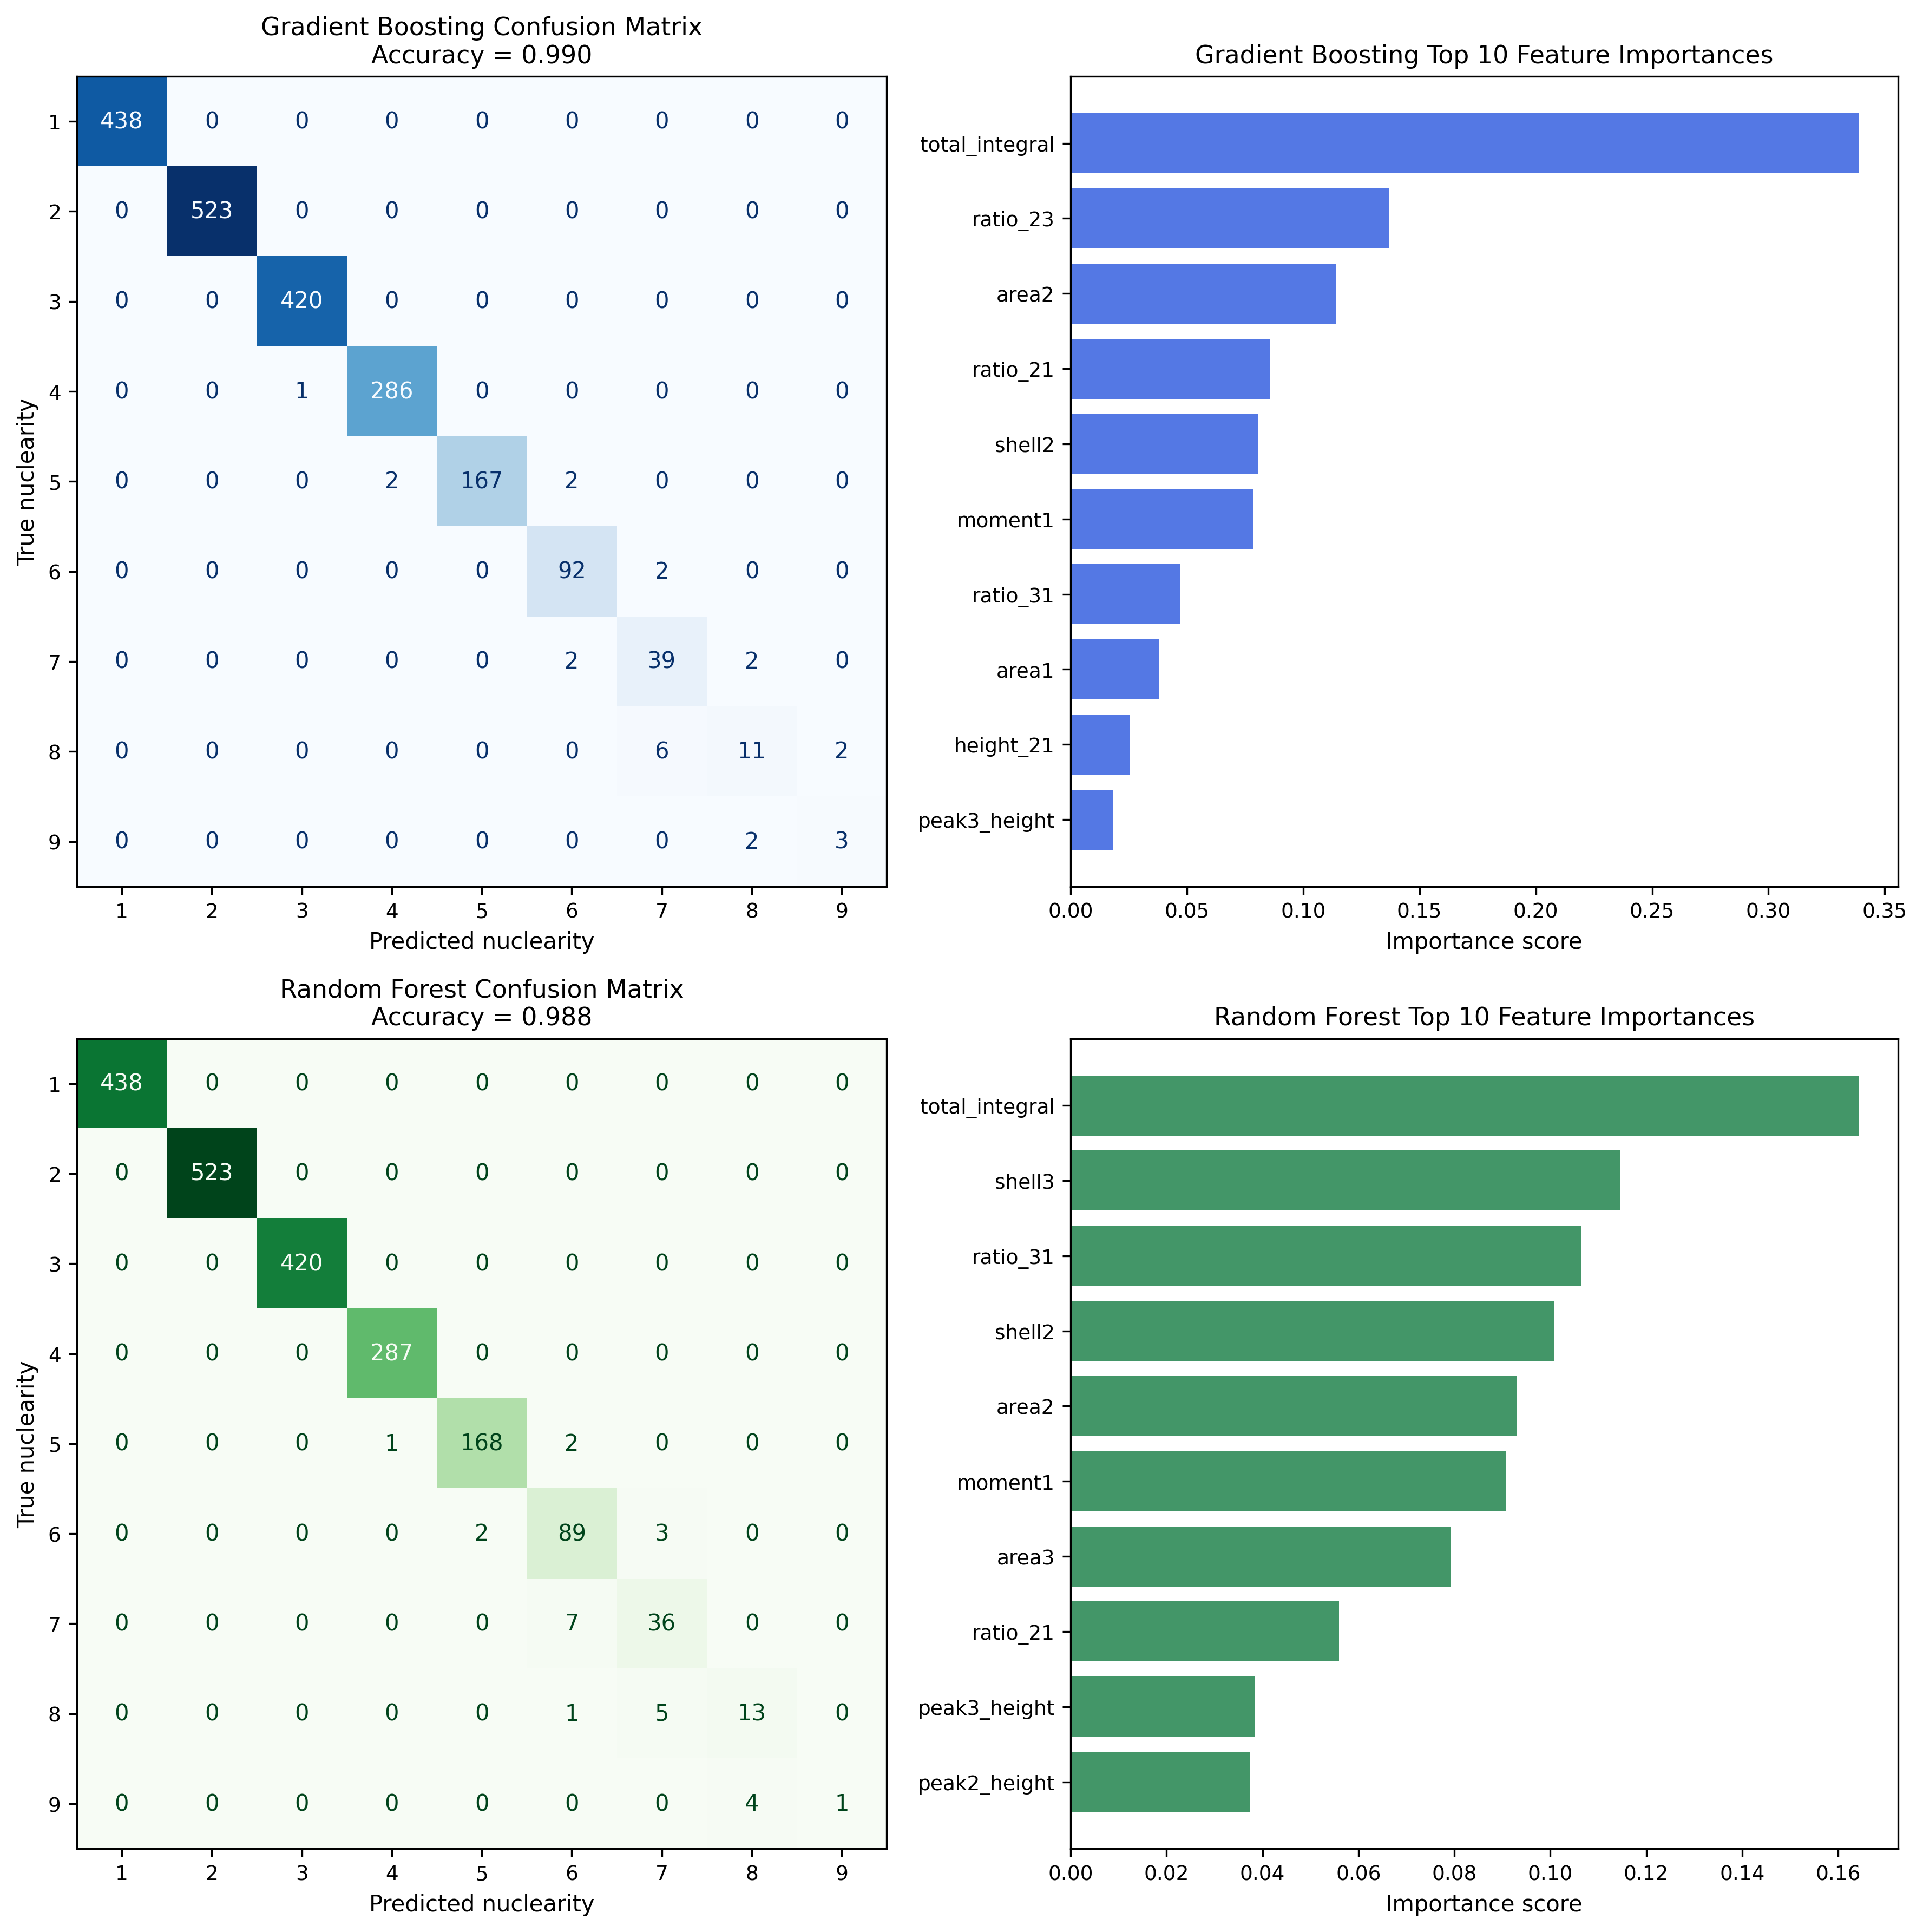

In [11]:
# Plot GB vs RF comparison together

# Guard checks for required upstream objects
required_vars = ['gb_classifier', 'best_rf', 'y_test', 'y_pred', 'y_pred_rf']
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise RuntimeError(
        "Run the model training cells first. Missing variables: " + ", ".join(missing_vars)
    )

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})

# Robust class extraction (no dependency on global y)
if 'y' in globals():
    classes = sorted(np.unique(y))
else:
    classes = sorted(np.unique(np.concatenate([y_test, y_pred, y_pred_rf])))

# Robust feature names
if 'feature_names' in globals() and len(feature_names) == gb_classifier.n_features_in_ + 1:
    feature_names_clean = feature_names[1:]
elif 'features_data' in globals() and 'nuclearity' in features_data.columns:
    feature_names_clean = [col for col in features_data.columns if col != 'nuclearity']
else:
    feature_names_clean = [f'feature_{i}' for i in range(gb_classifier.n_features_in_)]

# Metrics fallback
if 'accuracy' not in globals():
    accuracy = accuracy_score(y_test, y_pred)
if 'accuracy_rf' not in globals():
    accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Confusion matrices
cm_gb = confusion_matrix(y_test, y_pred, labels=classes)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=classes)

# Feature importances (sorted)
gb_importance = pd.Series(gb_classifier.feature_importances_, index=feature_names_clean).sort_values(ascending=False)
rf_importance = pd.Series(best_rf.feature_importances_, index=feature_names_clean).sort_values(ascending=False)
top_n = 10

# Build 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=300)
ax_cm_gb, ax_cm_rf = axes[0, 0], axes[1, 0]
ax_fi_gb, ax_fi_rf = axes[0, 1], axes[1, 1]

# 1) Confusion matrices
ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=classes).plot(
    ax=ax_cm_gb, cmap='Blues', values_format='d', colorbar=False
)
ax_cm_gb.set_title(f'Gradient Boosting Confusion Matrix\nAccuracy = {accuracy:.3f}')
ax_cm_gb.set_xlabel('Predicted nuclearity')
ax_cm_gb.set_ylabel('True nuclearity')

ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=classes).plot(
    ax=ax_cm_rf, cmap='Greens', values_format='d', colorbar=False
)
ax_cm_rf.set_title(f'Random Forest Confusion Matrix\nAccuracy = {accuracy_rf:.3f}')
ax_cm_rf.set_xlabel('Predicted nuclearity')
ax_cm_rf.set_ylabel('True nuclearity')

# 2) Feature importances (top N)
gb_top = gb_importance.head(top_n).sort_values(ascending=True)
rf_top = rf_importance.head(top_n).sort_values(ascending=True)

ax_fi_gb.barh(gb_top.index, gb_top.values, color='royalblue', alpha=0.9)
ax_fi_gb.set_title(f'Gradient Boosting Top {top_n} Feature Importances')
ax_fi_gb.set_xlabel('Importance score')

ax_fi_rf.barh(rf_top.index, rf_top.values, color='seagreen', alpha=0.9)
ax_fi_rf.set_title(f'Random Forest Top {top_n} Feature Importances')
ax_fi_rf.set_xlabel('Importance score')

fig.tight_layout()
plt.show()

## Model Training: Bayesian Classification

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import PolynomialFeatures

# Strategy 1: Feature Selection for Naive Bayes
print("1. Feature Selection for Naive Bayes")

def seeded_mutual_info(X_values, y_values):
    return mutual_info_classif(X_values, y_values, random_state=RANDOM_SEED)

# Use mutual information to select most informative features
selector = SelectKBest(score_func=seeded_mutual_info, k=10)  # Select top 10 features
X_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Get selected feature names
selected_features = np.array(feature_names_clean)[selector.get_support()]
print(f"Selected features: {list(selected_features)}")

# Train Naive Bayes on selected features
nb_improved = GaussianNB()
nb_improved.fit(X_selected, y_train)
y_pred_nb_improved = nb_improved.predict(X_test_selected)

accuracy_nb_improved = accuracy_score(y_test, y_pred_nb_improved)
f1_nb_improved = f1_score(y_test, y_pred_nb_improved, average='weighted')

print(f"Improved Naive Bayes: {accuracy_nb_improved:.3f} accuracy, {f1_nb_improved:.3f} F1")

# Strategy 2: Tuned Logistic Regression
print("\n2. Hyperparameter Tuning for Logistic Regression")

# Grid search for optimal regularization
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [5000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=RANDOM_SEED, multi_class='ovr'),
    param_grid_lr,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)
print(f"Best LogReg params: {lr_grid.best_params_}")

y_pred_lr_improved = lr_grid.predict(X_test_scaled)
accuracy_lr_improved = accuracy_score(y_test, y_pred_lr_improved)
f1_lr_improved = f1_score(y_test, y_pred_lr_improved, average='weighted')

print(f"Improved Logistic Regression: {accuracy_lr_improved:.3f} accuracy, {f1_lr_improved:.3f} F1")

# Strategy 3: Polynomial Features
print("\n3. Feature Engineering - Polynomial Features")

# Create polynomial features for top 5 most important features
feature_importance_rf = best_rf.feature_importances_
top_5_indices = np.argsort(feature_importance_rf)[-5:]
X_train_top5 = X_train_scaled[:, top_5_indices]
X_test_top5 = X_test_scaled[:, top_5_indices]

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_top5)
X_test_poly = poly.transform(X_test_top5)

print(f"Polynomial features: {X_train_poly.shape[1]} features from top 5")

# Train LogReg on polynomial features
lr_poly = LogisticRegression(C=1.0, random_state=RANDOM_SEED, max_iter=5000)
lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = lr_poly.predict(X_test_poly)

accuracy_lr_poly = accuracy_score(y_test, y_pred_lr_poly)
f1_lr_poly = f1_score(y_test, y_pred_lr_poly, average='weighted')

print(f"LogReg + Polynomial Features: {accuracy_lr_poly:.3f} accuracy, {f1_lr_poly:.3f} F1")

# Strategy 4: Ensemble
print("\n4. Ensemble of Bayesian Methods")

bayesian_ensemble = VotingClassifier([
    ('lr_tuned', lr_grid.best_estimator_),
    ('nb', GaussianNB())
], voting='soft')

bayesian_ensemble.fit(X_train_scaled, y_train)
y_pred_ensemble = bayesian_ensemble.predict(X_test_scaled)

accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble, average='weighted')

print(f"Bayesian Ensemble: {accuracy_ensemble:.3f} accuracy, {f1_ensemble:.3f} F1")

1. Feature Selection for Naive Bayes


Selected features: ['area2', 'area3', 'ratio_21', 'ratio_31', 'peak3_height', 'height_31', 'shell2', 'shell3', 'moment1', 'total_integral']
Improved Naive Bayes: 0.923 accuracy, 0.923 F1

2. Hyperparameter Tuning for Logistic Regression


Best LogReg params: {'C': 100, 'max_iter': 5000, 'solver': 'lbfgs'}
Improved Logistic Regression: 0.851 accuracy, 0.839 F1

3. Feature Engineering - Polynomial Features
Polynomial features: 15 features from top 5


LogReg + Polynomial Features: 0.932 accuracy, 0.930 F1

4. Ensemble of Bayesian Methods


Bayesian Ensemble: 0.932 accuracy, 0.931 F1


## Model Training: Simple Neural Network

In [13]:
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(RANDOM_SEED)

# Prepare data for neural network
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Neural network input: {X.shape[1]} PDF features")
print(f"Classes: {sorted(np.unique(y))}")

num_classes = len(np.unique(y))
y_categorical = keras.utils.to_categorical(y - 1, num_classes)  # -1 because nuclearity starts at 1

X_train, X_test, y_train, y_test, y_cat_train, y_cat_test = train_test_split(
    X, y, y_categorical, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Building neural network for PDF-based nuclearity classification...")

model = keras.Sequential([
    # Input layer with dropout for regularization
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden layers with decreasing size
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    
    # Output layer for classification
    layers.Dense(num_classes, activation='softmax')
])

# Compile with appropriate loss for classification
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'categorical_crossentropy']
)

print(f"Model architecture:")
model.summary()

# Training with early stopping and learning rate reduction
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
]

print("\nTraining neural network...")
num_epochs = 150
history = model.fit(
    X_train_scaled, y_cat_train,
    batch_size=64,
    epochs=num_epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# Evaluation and predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1) + 1  # +1 to convert back to nuclearity

# Calculate classification metrics
accuracy_nn = accuracy_score(y_test, y_pred_classes)
f1_weighted_nn = f1_score(y_test, y_pred_classes, average='weighted')
f1_macro_nn = f1_score(y_test, y_pred_classes, average='macro')

print(f"\nNeural Network Classification Results (PDF features):")
print(f"Accuracy: {accuracy_nn:.3f}")
print(f"F1-score (weighted): {f1_weighted_nn:.3f}")
print(f"F1-score (macro): {f1_macro_nn:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_classes, zero_division=0))


Neural network input: 20 PDF features
Classes: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Building neural network for PDF-based nuclearity classification...
Model architecture:
Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 128)               2688      


 batch_normalization (BatchN  (None, 128)              512       


...

 56/100 [===============>..............] - ETA: 0s - loss: 0.0611 - accuracy: 0.9768 - categorical_crossentropy: 0.0611

100/100 [==============================] - 0s 1ms/step - loss: 0.0574 - accuracy: 0.9781 - categorical_crossentropy: 0.0574 - val_loss: 0.0236 - val_accuracy: 0.9956 - val_categorical_crossentropy: 0.0236 - lr: 5.0000e-04


 1/63 [..............................] - ETA: 6s

63/63 [==============================] - 0s 447us/step



Neural Network Classification Results (PDF features):
Accuracy: 0.995
F1-score (weighted): 0.993
F1-score (macro): 0.849

Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       438
           2       1.00      1.00      1.00       523
           3       1.00      1.00      1.00       420
           4       1.00      1.00      1.00       287
           5       1.00      1.00      1.00       171
           6       1.00      1.00      1.00        94
           7       0.88      1.00      0.93        43
           8       0.72      0.68      0.70        19
           9       0.00      0.00      0.00         5

    accuracy                           0.99      2000
   macro avg       0.84      0.85      0.85      2000
weighted avg       0.99      0.99      0.99      2000



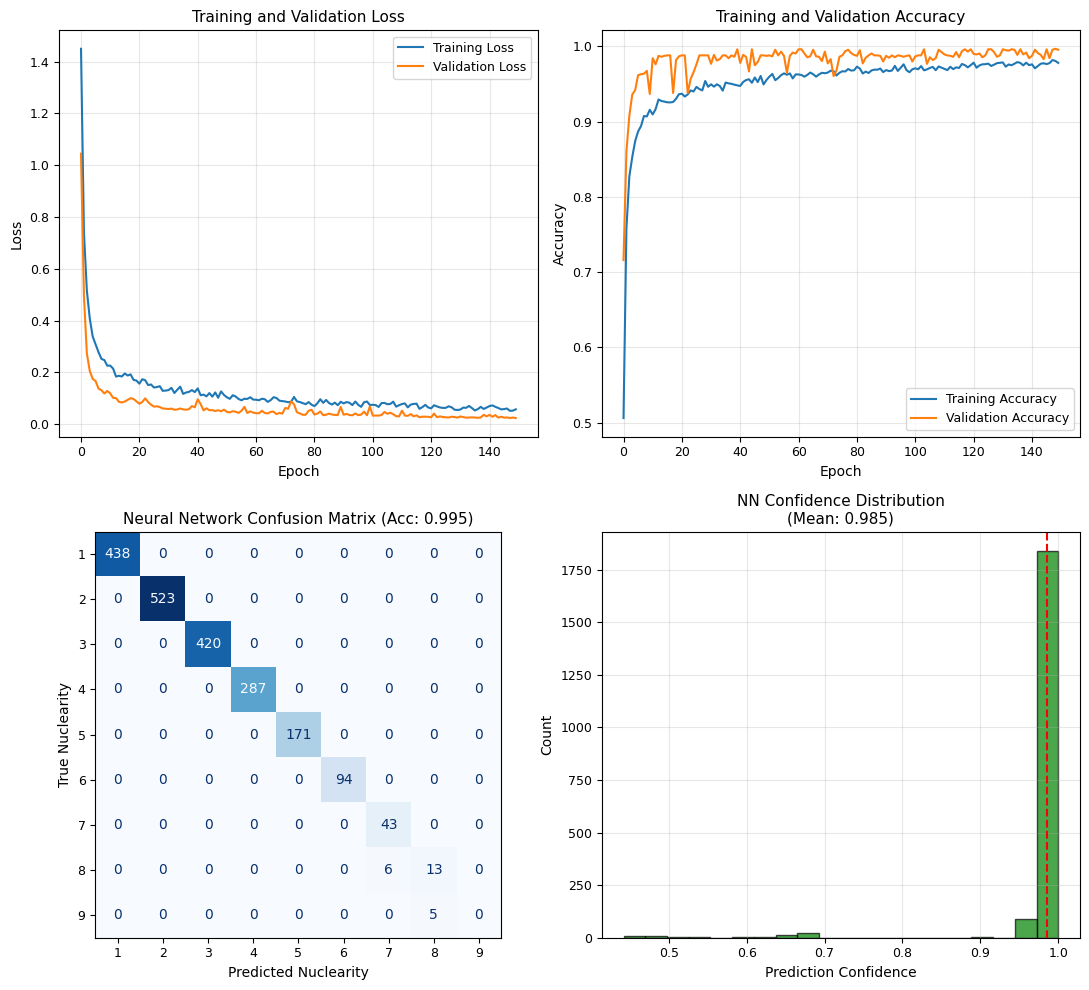

In [14]:
# Visualization: Training history and confusion matrix
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

# Training history - Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training history - Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion matrix
classes = sorted(np.unique(y))
conf_matrix_nn = confusion_matrix(y_test, y_pred_classes, labels=classes)
ConfusionMatrixDisplay(confusion_matrix=conf_matrix_nn, display_labels=classes).plot(
    ax=axes[1, 0], cmap='Blues', values_format='d', colorbar=False
)
axes[1, 0].set_xlabel('Predicted Nuclearity')
axes[1, 0].set_ylabel('True Nuclearity')
axes[1, 0].set_title(f'Neural Network Confusion Matrix (Acc: {accuracy_nn:.3f})')

# Prediction confidence distribution
confidence_scores = np.max(y_pred_prob, axis=1)
axes[1, 1].hist(confidence_scores, bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].set_xlabel('Prediction Confidence')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title(f'NN Confidence Distribution\n(Mean: {confidence_scores.mean():.3f})')
axes[1, 1].axvline(confidence_scores.mean(), color='red', linestyle='--')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Permutation explainer:  35%|█████████                 | 104/300 [00:00<?, ?it/s]

Permutation explainer:  35%|██████▎           | 106/300 [00:10<00:10, 19.39it/s]

Permutation explainer:  36%|██████▍           | 108/300 [00:10<00:14, 13.39it/s]

Permutation explainer:  37%|██████▌           | 110/300 [00:10<00:16, 11.58it/s]

...

Permutation explainer:  99%|█████████████████▊| 297/300 [00:28<00:00,  8.93it/s]

Permutation explainer: 100%|█████████████████▉| 299/300 [00:28<00:00,  9.73it/s]

Permutation explainer: 301it [00:29, 10.05it/s]                                 

Permutation explainer: 301it [00:29,  6.76it/s]

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


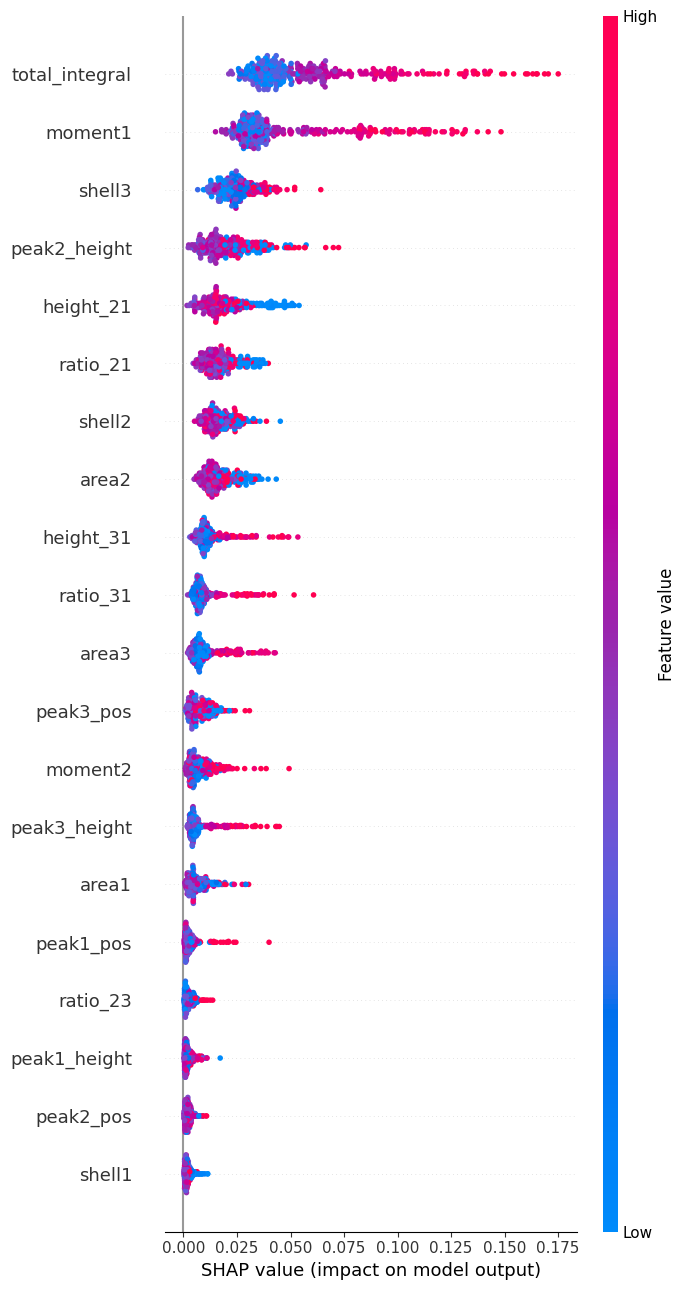

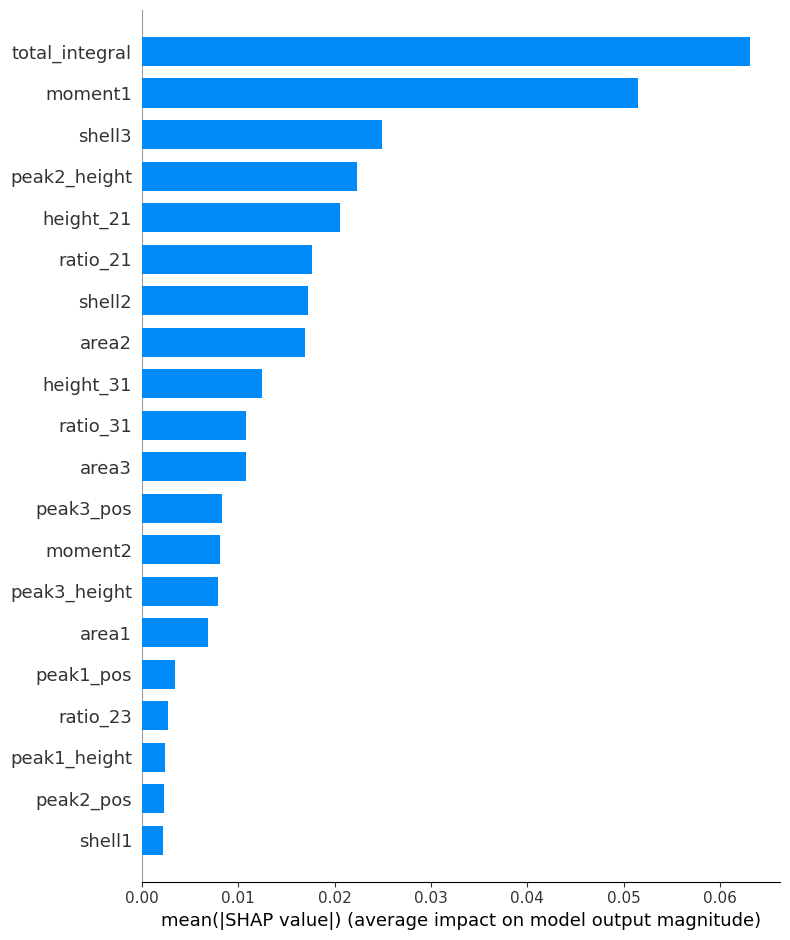

In [15]:
# SHAP explanations for the neural network
try:
    import shap
except ImportError as exc:
    raise ImportError("Install shap (pip install shap) before running this cell.") from exc

rng = np.random.default_rng(42)
background_size = min(200, X_train_scaled.shape[0])
sample_size = min(300, X_test_scaled.shape[0])

background_idx = rng.choice(X_train_scaled.shape[0], size=background_size, replace=False)
sample_idx = rng.choice(X_test_scaled.shape[0], size=sample_size, replace=False)

background = X_train_scaled[background_idx]
X_shap = X_test_scaled[sample_idx]

# Build SHAP explainer for the trained Keras model
explainer = shap.Explainer(model, background, feature_names=feature_names_clean)
shap_values = explainer(X_shap)

# For multi-class outputs, summarize by mean absolute contribution per feature
if hasattr(shap_values, "values") and shap_values.values.ndim == 3:
    shap_values_mean = shap.Explanation(
        values=np.mean(np.abs(shap_values.values), axis=2),
        base_values=np.mean(shap_values.base_values, axis=1) if shap_values.base_values.ndim == 2 else shap_values.base_values,
        data=shap_values.data,
        feature_names=shap_values.feature_names,
    )
    shap_to_plot = shap_values_mean
else:
    shap_to_plot = shap_values

# Summary plots
shap.summary_plot(shap_to_plot, features=X_shap, feature_names=feature_names_clean, show=True, plot_size=(7,13))
shap.summary_plot(shap_to_plot, features=X_shap, feature_names=feature_names_clean, plot_type="bar", show=True)

## Final Performance Comparison

In [16]:
print(f"\n" + "="*70)
print("FINAL ALGORITHM PERFORMANCE COMPARISON (PDF Features)")
print("="*70)
print(f"{'Algorithm':<35} {'Accuracy':<12} {'F1-Weighted':<12}")
print("-"*70)
print(f"{'Neural Network':<35} {accuracy_nn:.3f}        {f1_weighted_nn:.3f}")
print(f"{'Gradient Boosting':<35} {accuracy:.3f}        {f1_weighted:.3f}")
print(f"{'Random Forest':<35} {accuracy_rf:.3f}        {f1_weighted_rf:.3f}")
print(f"{'LogReg + Polynomial':<35} {accuracy_lr_poly:.3f}        {f1_lr_poly:.3f}")
print(f"{'Bayesian Ensemble':<35} {accuracy_ensemble:.3f}        {f1_ensemble:.3f}")
print(f"{'Naive Bayes (selected)':<35} {accuracy_nb_improved:.3f}        {f1_nb_improved:.3f}")
print(f"{'Tuned Logistic Regression':<35} {accuracy_lr_improved:.3f}        {f1_lr_improved:.3f}")
print("="*70)

# Identify best performing algorithms
algorithms = ['Gradient Boosting', 'Random Forest', 'Naive Bayes (improved)', 
              'Tuned LogReg', 'LogReg+Poly', 'Bayesian Ensemble', 'Neural Network']
accuracies = [accuracy, accuracy_rf, accuracy_nb_improved, 
              accuracy_lr_improved, accuracy_lr_poly, accuracy_ensemble, accuracy_nn]
f1_scores = [f1_weighted, f1_weighted_rf, f1_nb_improved, 
             f1_lr_improved, f1_lr_poly, f1_ensemble, f1_weighted_nn]

best_acc_idx = np.argmax(accuracies)
best_f1_idx = np.argmax(f1_scores)

print(f"\nBest Accuracy: {algorithms[best_acc_idx]} ({accuracies[best_acc_idx]:.3f})")
print(f"Best F1-Score: {algorithms[best_f1_idx]} ({f1_scores[best_f1_idx]:.3f})")

print("\n" + "="*70)
print(f"Analysis complete for {TAG}. All results are embedded in this notebook.")


FINAL ALGORITHM PERFORMANCE COMPARISON (PDF Features)
Algorithm                           Accuracy     F1-Weighted 
----------------------------------------------------------------------
Neural Network                      0.995        0.993
Gradient Boosting                   0.990        0.989
Random Forest                       0.988        0.987
LogReg + Polynomial                 0.932        0.930
Bayesian Ensemble                   0.932        0.931
Naive Bayes (selected)              0.923        0.923
Tuned Logistic Regression           0.851        0.839

Best Accuracy: Neural Network (0.995)
Best F1-Score: Neural Network (0.993)

Analysis complete for q0-11. All results are embedded in this notebook.
